# 02 — Delivery Delay Model

XGBoost binary classifier — predicts at order time whether delivery will be late.

**Contents:**
1. Feature analysis
2. Train XGBoost with Optuna tuning
3. Evaluation: ROC, PR curve, confusion matrix
4. SHAP feature importance
5. Error analysis

In [13]:
import sys, os
# Make project root importable regardless of where Jupyter is launched from
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to path ✓")

Project root added to path ✓


In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import mlflow

from data_loader import OlistLoader
from ml.delivery_delay_model import DeliveryDelayModel

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="darkgrid")

loader = OlistLoader()
df = loader.order_features()
df = df[df["order_status"] == "delivered"].dropna(subset=["is_late"])

print(f"Dataset: {len(df):,} delivered orders")
print(f"Late rate: {df['is_late'].mean():.1%}  (class imbalance — this is why we tune threshold)")

2026-03-06 20:36:47.161 | INFO     | data_loader:__init__:65 - OlistLoader ready — 9/9 CSV files found in C:\Users\luizg\Downloads\ProjetoGithub\olist-ecommerce-platform\data
2026-03-06 20:36:47.163 | INFO     | data_loader:order_features:129 - Building order_features table...
2026-03-06 20:36:47.582 | DEBUG    | data_loader:_read:295 - Loaded orders: 99,441 rows from olist_orders_dataset.csv
2026-03-06 20:36:47.916 | DEBUG    | data_loader:_read:295 - Loaded order_items: 112,650 rows from olist_order_items_dataset.csv
2026-03-06 20:36:47.994 | DEBUG    | data_loader:_read:295 - Loaded order_payments: 103,886 rows from olist_order_payments_dataset.csv
2026-03-06 20:36:48.315 | DEBUG    | data_loader:_read:295 - Loaded order_reviews: 99,224 rows from olist_order_reviews_dataset.csv
2026-03-06 20:36:48.439 | DEBUG    | data_loader:_read:295 - Loaded customers: 99,441 rows from olist_customers_dataset.csv
2026-03-06 20:36:48.444 | DEBUG    | data_loader:_read:295 - Loaded sellers: 3,095 r

Dataset: 96,478 delivered orders
Late rate: 7.6%  (class imbalance — this is why we tune threshold)


## 1. Feature Analysis

In [15]:
feature_cols = [
    "item_count", "total_price", "total_freight", "freight_ratio",
    "estimated_days", "max_installments", "purchase_month", "purchase_hour"
]

stats = df.groupby("is_late")[feature_cols].mean().T
stats.columns = ["On Time", "Late"]
stats["Difference %"] = ((stats["Late"] - stats["On Time"]) / stats["On Time"] * 100).round(1)
print("Feature means — On Time vs Late:")
print(stats.to_string())

Feature means — On Time vs Late:
                  On Time     Late  Difference %
item_count         1.1444   1.1148       -2.6000
total_price      136.0599 149.0221        9.5000
total_freight     22.6132  24.8848       10.0000
freight_ratio      0.2936   0.3000        2.2000
estimated_days    23.4967  21.8605       -7.0000
max_installments   2.9208   3.0166        3.3000
purchase_month     6.0572   5.7129       -5.7000
purchase_hour     14.7815  14.6722       -0.7000


## 2. Train the Model

In [16]:

model = DeliveryDelayModel(n_trials=30)
metrics = model.train(df)

print("\n── Test set metrics ──")
for k, v in metrics.items():
    print(f"  {k:<20} {v:.4f}")

2026-03-06 20:37:09.146 | INFO     | ml.delivery_delay_model:train:108 - Split — train: 67,534  val: 14,472  test: 14,472
2026-03-06 20:37:09.148 | INFO     | ml.delivery_delay_model:train:114 - Class imbalance — scale_pos_weight: 10.71
2026-03-06 20:37:40.514 | INFO     | ml.delivery_delay_model:_tune:268 - Best Optuna AP: 0.1166
2026-03-06 20:37:43.389 | INFO     | ml.delivery_delay_model:train:138 - Optimal threshold: 0.430
2026-03-06 20:37:43.426 | INFO     | ml.delivery_delay_model:_evaluate:284 - 
              precision    recall  f1-score   support

           0       0.97      0.66      0.79     13650
           1       0.11      0.68      0.19       822

    accuracy                           0.66     14472
   macro avg       0.54      0.67      0.49     14472
weighted avg       0.92      0.66      0.75     14472

2026-03-06 20:37:43.875 | INFO     | ml.delivery_delay_model:_compute_shap:296 - SHAP values computed
2026-03-06 20:37:43.882 | INFO     | ml.delivery_delay_model:_

🏃 View run delivery_delay_xgb at: http://localhost:5000/#/experiments/1/runs/354d5db11df14f3a947dc50904dd484e
🧪 View experiment at: http://localhost:5000/#/experiments/1

── Test set metrics ──
  auc_roc              0.7230
  avg_precision        0.1143
  f1                   0.1884
  precision            0.1092
  recall               0.6849


## 3. Evaluation Curves

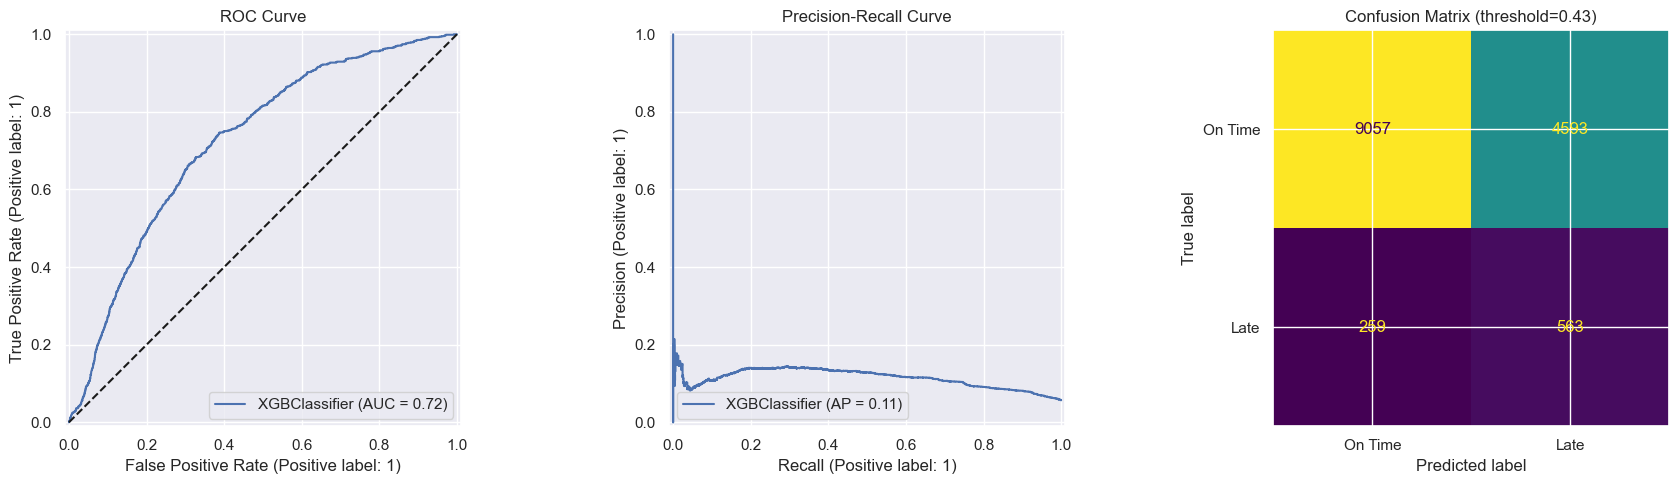

In [17]:
df = model._prepare(df)
X = df[model.feature_names].fillna(0)
y = df["is_late"]

n = len(X)
X_test = X.iloc[int(n * 0.85):]
y_test = y.iloc[int(n * 0.85):]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_estimator(model.model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve")
axes[0].plot([0, 1], [0, 1], "k--")

PrecisionRecallDisplay.from_estimator(model.model, X_test, y_test, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

proba = model.model.predict_proba(X_test)[:, 1]
preds = (proba >= model.threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, preds, ax=axes[2],
    display_labels=["On Time", "Late"], colorbar=False
)
axes[2].set_title(f"Confusion Matrix (threshold={model.threshold:.2f})")

plt.tight_layout()
plt.show()

## 4. SHAP Feature Importance

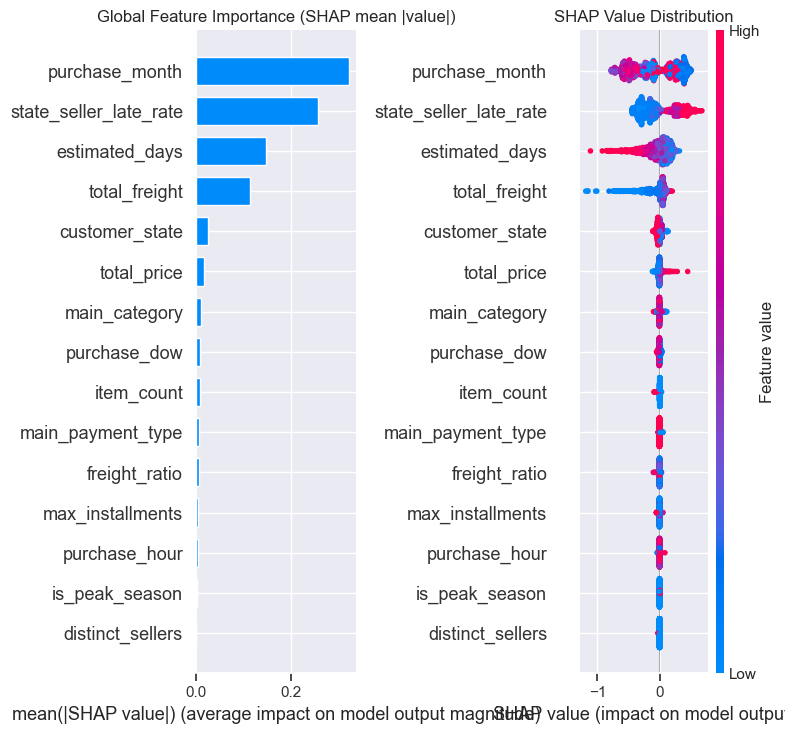

In [18]:
X_train = X.iloc[:int(n * 0.70)]
X_sample = X_train.sample(min(1500, len(X_train)), random_state=42)

explainer   = shap.TreeExplainer(model.model)
shap_values = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
axes[0].set_title("Global Feature Importance (SHAP mean |value|)")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
axes[1].set_title("SHAP Value Distribution")

plt.tight_layout()
plt.show()

## 5. Error Analysis

In [19]:
results = df.iloc[int(n * 0.85):].copy()
results["delay_probability"] = proba
results["predicted_late"]    = preds

fn = results[(results["predicted_late"] == 0) & (results["is_late"] == 1)]
fp = results[(results["predicted_late"] == 1) & (results["is_late"] == 0)]

print(f"False Negatives (missed late deliveries): {len(fn):,}")
print(f"False Positives (unnecessary alerts):     {len(fp):,}")
print()
print("False negatives — feature averages:")
print(fn[["estimated_days", "total_price", "freight_ratio", "customer_state"]].describe().loc[["mean","50%"]].to_string())
print()
print("Top states in false negatives:")
print(fn["customer_state"].value_counts().head(8).to_string())

False Negatives (missed late deliveries): 259
False Positives (unnecessary alerts):     4,593

False negatives — feature averages:
      estimated_days  total_price  freight_ratio  customer_state
mean         14.2162     111.5714         0.2964         21.0888
50%          13.0000      69.0000         0.2491         25.0000

Top states in false negatives:
customer_state
25    159
18     35
10     18
17     11
22     11
6       8
8       6
23      4
